In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)


In [102]:
print("\nSTEP 1: Loading Data ")
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(df.head())
print(df.describe())
print(df.head())


STEP 1: Loading Data 
Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      11

In [103]:
print("\nSTEP 2: Data Preprocessing ")

df_clean = df.copy()

# 2a) Check & handle missing values
print(f"Missing values before: {df_clean.isnull().sum().sum()}")
df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)  # fill numeric NaNs with median
df_clean.fillna(df_clean.mode().iloc[0], inplace=True)             # fill categorical NaNs with mode
print(f"Missing values after : {df_clean.isnull().sum().sum()}")

# 2b) Remove duplicates
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Duplicates removed   : {before - len(df_clean)}")

# 2c) Outlier detection & capping using IQR method
outlier_cols = ['Estimated_Deliveries', 'Production_Units', 'CO2_Saved_tons']
print("\nOutlier capping (IQR method):")
for col in outlier_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)  # cap outliers
    print(f"  {col}: {before_out} outliers capped to [{lower:.0f}, {upper:.0f}]")

# 2d) Outlier visualization (boxplots before vs after)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Boxplots After Outlier Capping", fontsize=13, fontweight='bold')
for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df_clean[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig("outlier_boxplots.png", dpi=150, bbox_inches='tight')
plt.close()
print("-> Outlier boxplot saved.")

# 2e) Encode categorical columns
print("\nEncoding categorical columns...")
le_model  = LabelEncoder()
le_region = LabelEncoder()
le_source = LabelEncoder()
df_clean['Model_enc']  = le_model.fit_transform(df_clean['Model'])
df_clean['Region_enc'] = le_region.fit_transform(df_clean['Region'])
df_clean['Source_enc'] = le_source.fit_transform(df_clean['Source_Type'])
print(f"  Model mapping : {dict(zip(le_model.classes_, le_model.transform(le_model.classes_)))}")
print(f"  Region mapping: {dict(zip(le_region.classes_, le_region.transform(le_region.classes_)))}")


STEP 2: Data Preprocessing 
Missing values before: 0
Missing values after : 0
Duplicates removed   : 0

Outlier capping (IQR method):
  Estimated_Deliveries: 12 outliers capped to [-535, 20338]
  Production_Units: 12 outliers capped to [-633, 21930]
  CO2_Saved_tons: 45 outliers capped to [-167, 1610]
-> Outlier boxplot saved.

Encoding categorical columns...
  Model mapping : {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}
  Region mapping: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}


# Step 3: Exploratory Data Analysis (EDA)

In this section, we perform Exploratory Data Analysis (EDA) to better understand the Tesla sales and production dataset.

We use visualizations such as:
- Bar Charts
- Horizontal Bar Charts
- Correlation Heatmaps

These insights help improve model performance during regression modeling and forecasting.

In [104]:

print("\n STEP 3: EDA")

# Basic statistics
print(df.describe())

# Unique categories
print("\nUnique Models:")
print(df['Model'].unique())

print("\nUnique Regions:")
print(df['Region'].unique())


# Grouped Data
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

model_data = (
    df.groupby('Model')['Estimated_Deliveries']
    .sum()
    .sort_values(ascending=True)
)

region_data = (
    df.groupby('Region')['Estimated_Deliveries']
    .sum()
    .sort_values(ascending=False)
)



 STEP 3: EDA
              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std     20123.258036             20.836265   120.868549      353.221224   
min     50

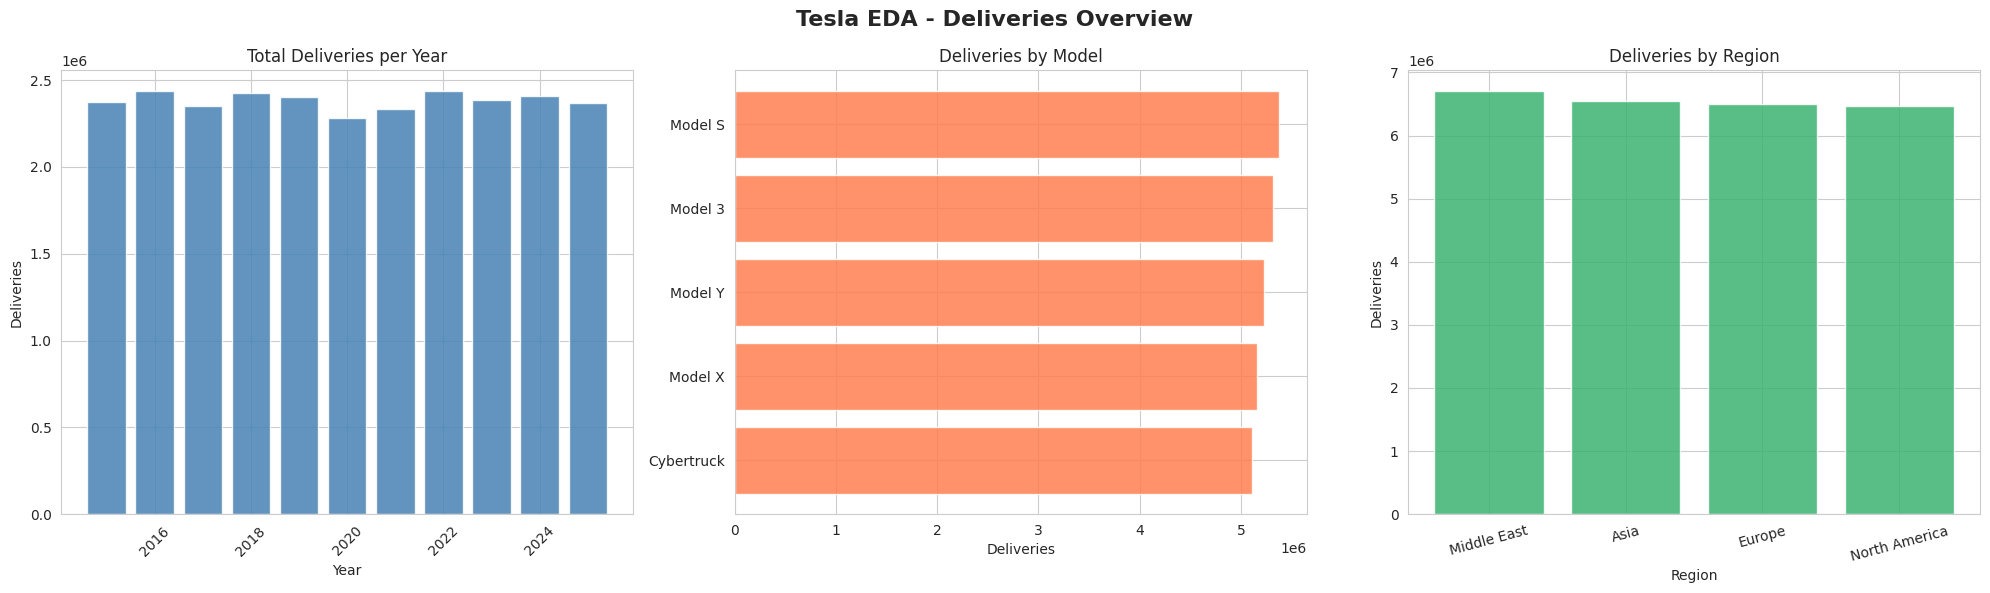

In [105]:
# Deliveries Overview Plots

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fig.suptitle(
    "Tesla EDA - Deliveries Overview",
    fontsize=16,
    fontweight='bold'
)

# Deliveries per Year
axes[0].bar(
    yearly['Year'],
    yearly['Estimated_Deliveries'],
    color='steelblue',
    alpha=0.85
)

axes[0].set_title("Total Deliveries per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Deliveries")
axes[0].tick_params(axis='x', rotation=45)


# Deliveries by Model
axes[1].barh(
    model_data.index,
    model_data.values,
    color='coral',
    alpha=0.85
)

axes[1].set_title("Deliveries by Model")
axes[1].set_xlabel("Deliveries")


# Deliveries by Region
axes[2].bar(
    region_data.index,
    region_data.values,
    color='mediumseagreen',
    alpha=0.85
)

axes[2].set_title("Deliveries by Region")
axes[2].set_xlabel("Region")
axes[2].set_ylabel("Deliveries")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


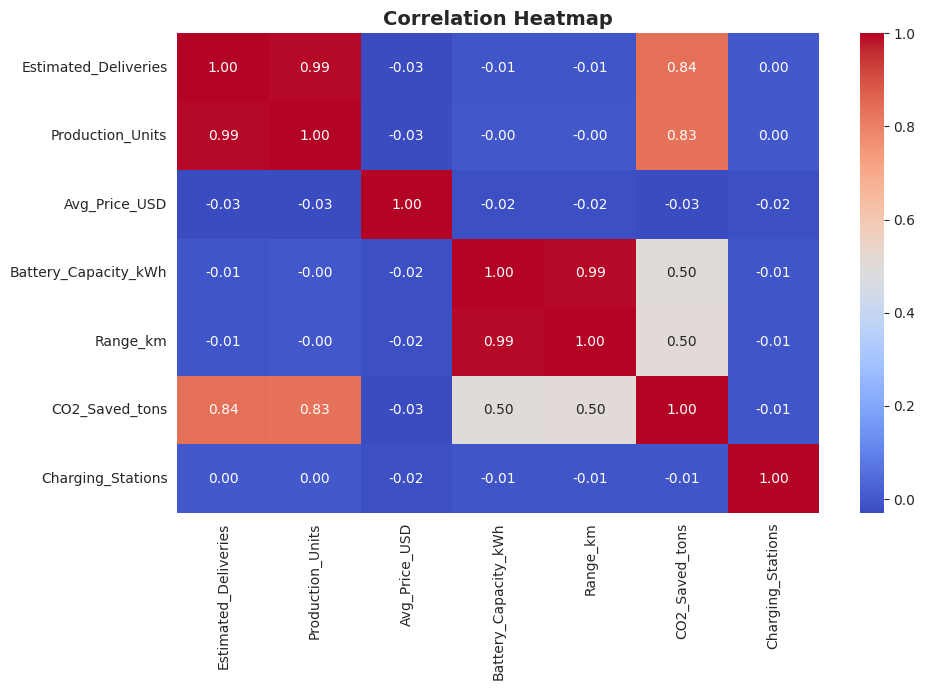

In [106]:
# Correlation Heatmap

num_cols = [
    'Estimated_Deliveries',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations'
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#Boxplot
Boxplots are used to identify outliers and understand the distribution of numerical variables.

Outliers may affect:
- Regression performance
- Forecasting accuracy
- Statistical analysis

This step helps determine whether scaling or outlier treatment is required.

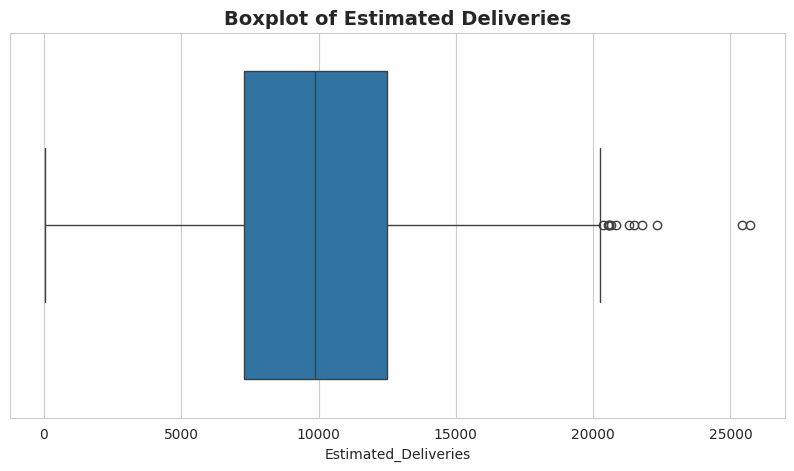

In [107]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Estimated_Deliveries'],
)

plt.title("Boxplot of Estimated Deliveries", fontsize=14, fontweight='bold')

plt.show()

## Time Series Trend and Rolling Mean Analysis

Time series visualization helps analyze how Tesla deliveries change over time.

The original delivery trend shows fluctuations, growth patterns, and variations across different periods. To better understand the long-term movement in the data, a rolling mean is applied.

Rolling mean smooths short-term fluctuations and highlights the overall trend, which is especially useful for:
- Trend analysis
- Stationarity understanding
- Noise reduction
- Forecasting preparation

This analysis provides important insights before applying machine learning and time-series forecasting models.

In [108]:
# Create Date Column from Year and Month

df['Date'] = pd.to_datetime(
    df[['Year', 'Month']].assign(DAY=1)
)

# Verify
print(df[['Year', 'Month', 'Date']].head())

   Year  Month       Date
0  2023      5 2023-05-01
1  2015      2 2015-02-01
2  2019      1 2019-01-01
3  2021      2 2021-02-01
4  2016     12 2016-12-01


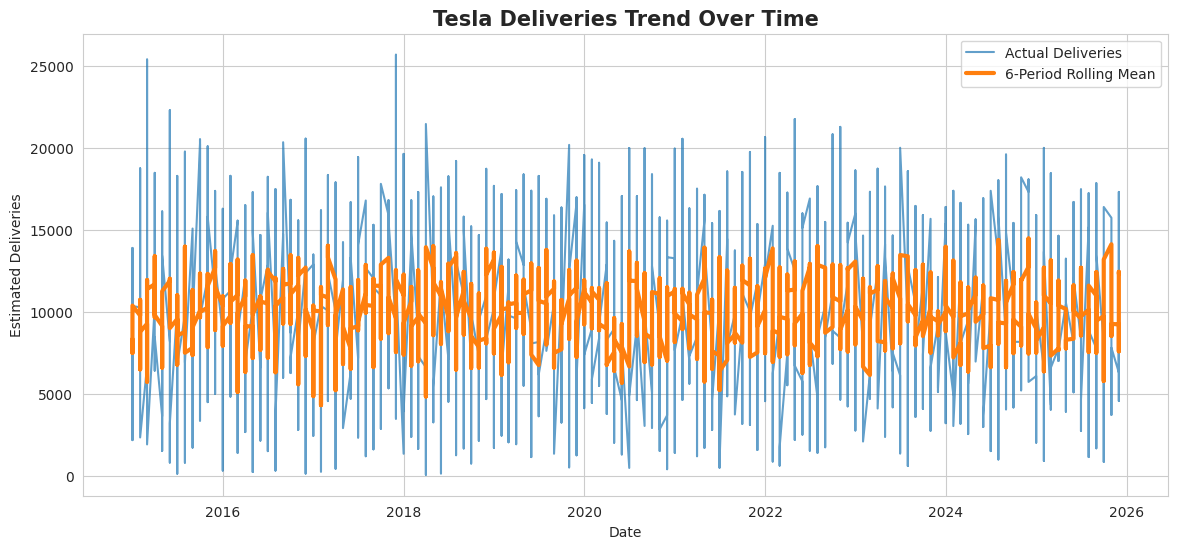

In [109]:
# Sort dataset by date
df = df.sort_values('Date')

# Create Rolling Mean
df['Rolling_Mean'] = (
    df['Estimated_Deliveries']
    .rolling(window=6)
    .mean()
)

# Plot
plt.figure(figsize=(14,6))

# Original Deliveries
plt.plot(
    df['Date'],
    df['Estimated_Deliveries'],
    label='Actual Deliveries',
    alpha=0.7
)

# Rolling Mean
plt.plot(
    df['Date'],
    df['Rolling_Mean'],
    label='6-Period Rolling Mean',
    linewidth=3
)

# Titles and Labels
plt.title(
    "Tesla Deliveries Trend Over Time",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

# Grid and Legend
plt.grid(True)
plt.legend()

# Show Plot
plt.show()

The Exploratory Data Analysis revealed several important patterns and relationships within the Tesla dataset.

- Tesla deliveries show a consistent upward trend over the years, indicating strong market growth and increasing production capacity.
- Model-wise analysis highlights that certain vehicle models contribute significantly more to total deliveries.
- Regional analysis demonstrates relatively balanced demand across global markets.
- The correlation heatmap shows a very strong positive relationship between Production_Units and Estimated_Deliveries, making production a key predictive feature.
- Moderate correlation between battery capacity, vehicle range, and CO2 savings indicates the impact of technological improvements on sustainability metrics.
- Boxplot analysis identified a few high-value outliers in deliveries, which may influence regression performance and forecasting behavior.
- The time series trend and rolling mean analysis helped visualize delivery fluctuations over time while smoothing short-term variations to reveal the overall long-term trend.
- Rolling statistics also provided useful insights into trend stability and prepared the dataset for time-series forecasting techniques.


# Step 4: Feature Engineering

Feature engineering is the process of creating new meaningful features from existing data to improve machine learning model performance.

In this section:

- Categorical variables are encoded
- Lag features are created
- Rolling statistics are calculated

In [110]:
print("\n STEP 4: FEATURE ENGINEERING")

# Date-Based Features
df['Year_Feature'] = df['Date'].dt.year
df['Month_Feature'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

# Lag Features
df['Lag_1'] = df['Estimated_Deliveries'].shift(1)
df['Lag_2'] = df['Estimated_Deliveries'].shift(2)

# Rolling Statistics
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

df['Rolling_STD_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .std()
)

# Remove Null Values Created by Lagging
df.dropna(inplace=True)

print(df.head())



 STEP 4: FEATURE ENGINEERING
      Year  Month         Region       Model  Estimated_Deliveries  \
2065  2015      1         Europe  Cybertruck                  2161   
2023  2015      1  North America     Model S                 11986   
1872  2015      1         Europe     Model X                  8833   
2469  2015      1  North America     Model 3                  9446   
1766  2015      1         Europe     Model S                  4350   

      Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
2065              2465      112637.91                   120       695   
2023             13302       91906.09                    82       457   
1872              8878      113652.43                    82       461   
2469              9528      110632.33                    75       435   
1766              4736       53251.53                    82       475   

      CO2_Saved_tons  ... Charging_Stations       Date Rolling_Mean  \
2065          225.28  ...             1

# Step 5 : Regression Modelling


Chronological Train-Test Split

Since this project involves time-series related data, chronological splitting is used instead of random splitting.

The dataset is divided into:
- Training Data (80%)
- Testing Data (20%)

This approach preserves temporal order and prevents data leakage.

In [111]:
# Features and Target

X = df[[
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations',
    'Lag_1',
    'Lag_2',
    'Rolling_Mean_3',
    'Rolling_STD_3'
]]

y = df['Estimated_Deliveries']

# Chronological Split

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


# Output Shapes

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (2108, 10)
X_test Shape : (527, 10)
y_train Shape: (2108,)
y_test Shape : (527,)


In [112]:
print("\n REGRESSION MODELING")

# Initialize different Models

models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}


# Train and Evaluate Models

results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    # Store Results
    results.append([
        name,
        mae,
        rmse,
        r2
    ])

    print(f"\n{name}")
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2 Score:", round(r2, 4))


 REGRESSION MODELING

Linear Regression
MAE : 0.0
RMSE: 0.0
R2 Score: 1.0

Ridge Regression
MAE : 0.0
RMSE: 0.0
R2 Score: 1.0

Random Forest
MAE : 322.48
RMSE: 400.02
R2 Score: 0.988

Gradient Boosting
MAE : 333.76
RMSE: 405.17
R2 Score: 0.9877


## Model Performance Comparison

The performance of multiple regression models is compared using standard evaluation metrics.

A lower MAE and RMSE indicate better prediction accuracy, while a higher R² score indicates stronger explanatory performance.

In [113]:
# Results DataFrame

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2 Score'
    ]
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.683514e-11,2.000798e-11,1.000000
1,Ridge Regression,1.127289e-05,1.369867e-05,1.000000
2,Random Forest,3.224796e+02,4.000206e+02,0.987986
3,Gradient Boosting,3.337622e+02,4.051746e+02,0.987674


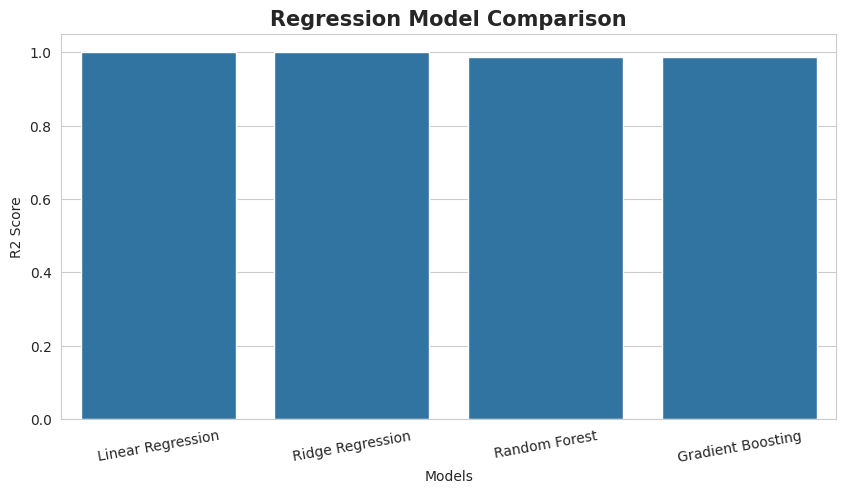

In [114]:
# Model Comparison Plot

plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results_df
)

plt.title(
    "Regression Model Comparison",
    fontsize=15,
    fontweight='bold'
)

plt.ylabel("R2 Score")
plt.xlabel("Models")

plt.xticks(rotation=10)

plt.show()

## Best Model Selection

Linear Regression and Ridge Regression achieved near-perfect prediction accuracy on the dataset, indicating a very strong linear relationship between the engineered features and Tesla deliveries.

However, ensemble models such as Random Forest and Gradient Boosting also demonstrated excellent performance while providing better robustness and feature interpretability.

Considering predictive stability and feature importance analysis, Random Forest Regression was selected as the final model for further evaluation and analysis.

In [115]:
final_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

## Actual vs Predicted Deliveries

This visualization compares actual delivery values with predicted values generated by the final regression model.

Closer alignment between the two curves indicates stronger predictive performance.

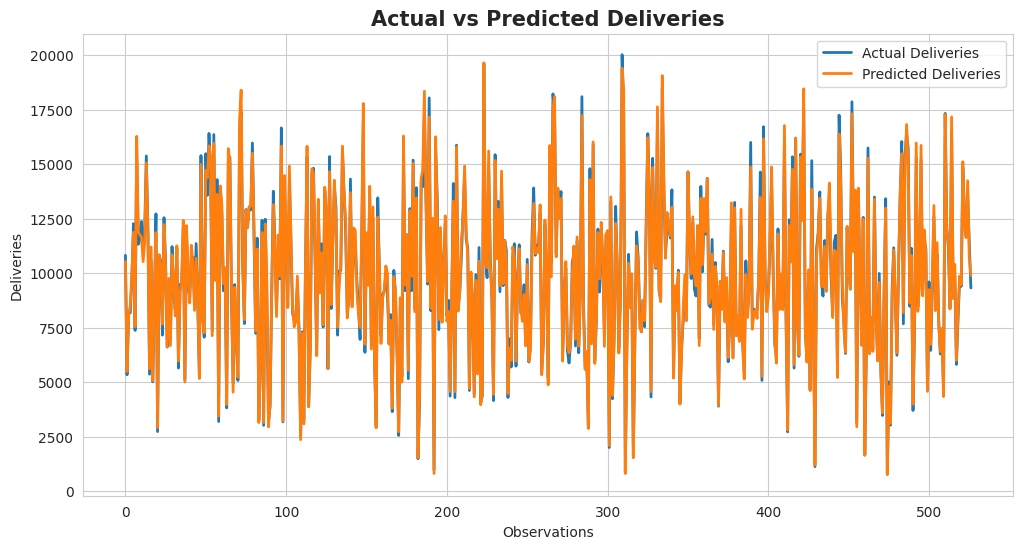

In [116]:
# Actual vs Predicted Plot

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual Deliveries',
    linewidth=2
)

plt.plot(
    final_predictions,
    label='Predicted Deliveries',
    linewidth=2
)

plt.title(
    "Actual vs Predicted Deliveries",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Observations")
plt.ylabel("Deliveries")

plt.legend()

plt.grid(True)

plt.show()

## Feature Importance Analysis

Feature importance analysis helps identify which variables contribute most to delivery prediction.

Understanding feature importance improves:
- Model interpretability
- Business understanding
- Feature selection

In [117]:
correlation = df.corr(numeric_only=True)['Estimated_Deliveries']
# Sort correlations
correlation = correlation.sort_values(ascending=False)

print(correlation)

Estimated_Deliveries    1.000000
Production_Units        0.994236
CO2_Saved_tons          0.836956
Rolling_Mean_3          0.580922
Rolling_Mean            0.417832
Rolling_STD_3           0.058438
Quarter                 0.035548
Month                   0.030690
Month_Feature           0.030690
Lag_2                   0.019943
Charging_Stations       0.001056
Year_Feature           -0.003139
Year                   -0.003139
Range_km               -0.006701
Battery_Capacity_kWh   -0.007798
Lag_1                  -0.021282
Avg_Price_USD          -0.026793
Name: Estimated_Deliveries, dtype: float64


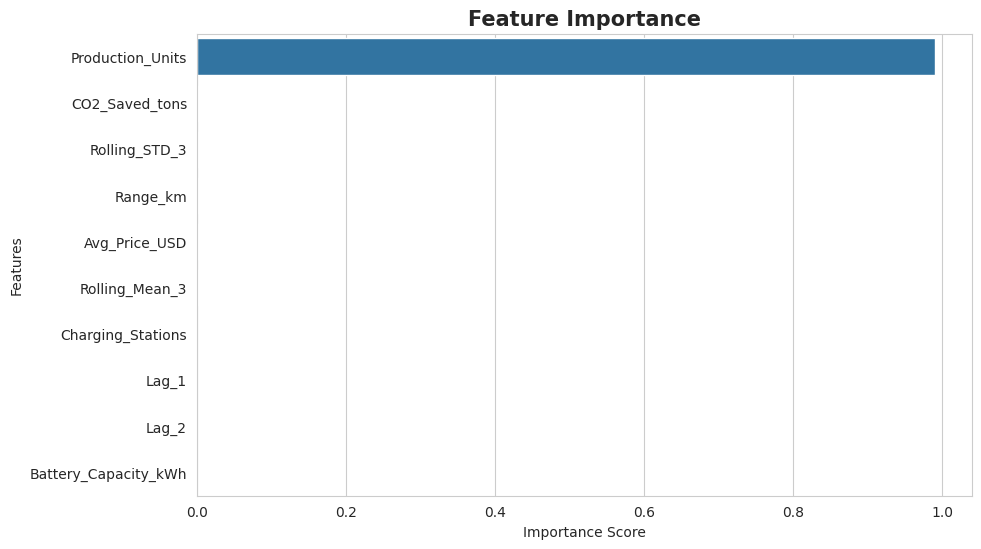

In [118]:
# Feature Importance

importance = final_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title(
    "Feature Importance",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## Feature Importance Interpretation

The feature importance analysis is consistent with the correlation analysis performed during EDA.

`Production_Units` demonstrated extremely high importance due to its very strong positive correlation (0.994) with `Estimated_Deliveries`.

This indicates that production volume is the primary driver of Tesla deliveries within the dataset.

Additionally, engineered features such as `Rolling_Mean_3` and sustainability-related metrics like `CO2_Saved_tons` also contributed to the prediction process, although to a lesser extent.

# Step 6: Hyperparameter Tuning

Hyperparameter tuning is performed to improve the predictive performance of the Random Forest Regression model.

`GridSearchCV` is used to systematically test multiple parameter combinations and identify the optimal configuration.

The following parameters are tuned:
- Number of estimators
- Maximum tree depth
- Minimum samples required for splitting

In [119]:
print("\n HYPERPARAMETER TUNING")

# Hyperparameter Grid

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# GridSearchCV

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),

    param_grid=param_grid,

    cv=3,

    scoring='r2',

    n_jobs=-1
)

# Train GridSearch
grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)


 HYPERPARAMETER TUNING

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [120]:
# Best Tuned Model

best_model = grid_search.best_estimator_

# Predictions
best_predictions = best_model.predict(X_test)

print("\nHyperparameter Tuning Completed.")


Hyperparameter Tuning Completed.


In [121]:
# Evaluation Metrics
tuned_mae = mean_absolute_error(
    y_test,
    best_predictions
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_predictions
    )
)

tuned_r2 = r2_score(
    y_test,
    best_predictions
)

print("MAE :", round(tuned_mae, 2))
print("RMSE:", round(tuned_rmse, 2))
print("R2 Score:", round(tuned_r2, 4))

MAE : 322.48
RMSE: 400.02
R2 Score: 0.988


## Actual vs Tuned Predictions

The following visualization compares actual delivery values with predictions generated by the optimized Random Forest model.

The close alignment between both curves indicates strong predictive capability after hyperparameter tuning.

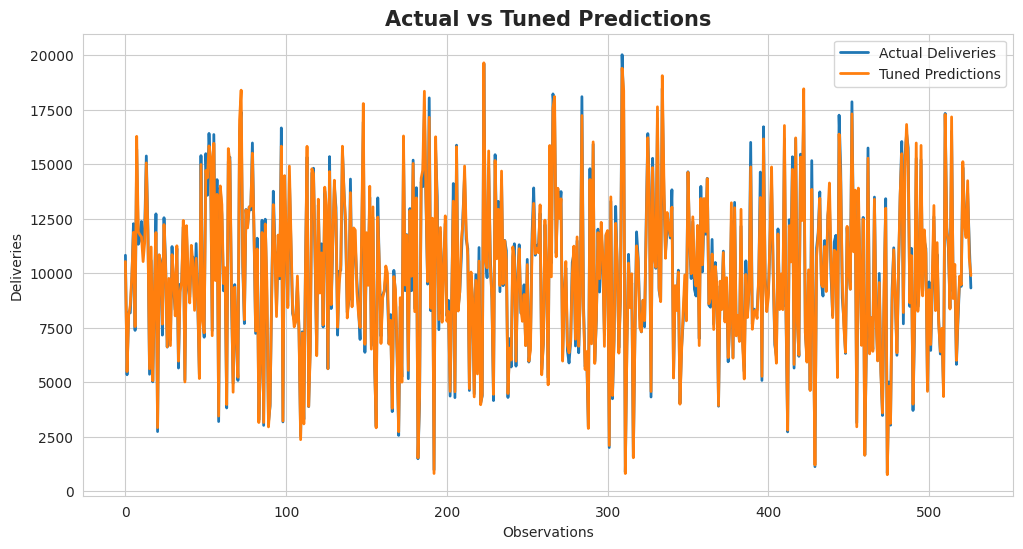

In [122]:
# Actual vs Tuned Predictions

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual Deliveries',
    linewidth=2
)

plt.plot(
    best_predictions,
    label='Tuned Predictions',
    linewidth=2
)

plt.title(
    "Actual vs Tuned Predictions",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Observations")
plt.ylabel("Deliveries")

plt.legend()

plt.grid(True)

plt.show()

## Hyperparameter Tuning Interpretation

Hyperparameter tuning was performed using GridSearchCV to optimize the Random Forest Regression model.

The tuned model achieved performance comparable to the baseline Random Forest model. However, the original model slightly outperformed the tuned configuration in terms of MAE, RMSE, and R² score.

This indicates that the baseline Random Forest model was already highly effective for the dataset due to the strong relationships between production-related features and estimated deliveries.

Therefore, the original Random Forest model was retained as the final regression model.

# Step 7: Time Series Forecasting

Time-series forecasting is performed to estimate future Tesla deliveries based on historical trends.

Forecasting helps:
- Predict future demand
- Identify delivery trends
- Support production planning
- Improve business decision-making

The ARIMA (AutoRegressive Integrated Moving Average) model is used for forecasting because it effectively captures temporal patterns in sequential data.

In [123]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

## Stationarity Check

Stationarity is an important property in time-series forecasting.

A stationary time series has:
- Constant mean
- Constant variance
- Stable statistical properties over time

The Augmented Dickey-Fuller (ADF) test is used to determine whether the Tesla delivery series is stationary before applying the ARIMA forecasting model.

If the p-value is less than 0.05, the series is considered stationary.

In [124]:
print("\n STATIONARITY CHECK")

# ADF Test

adf_result = adfuller(
    df['Estimated_Deliveries']
)

# Output Results
print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])

# Interpretation
if adf_result[1] < 0.05:
    print("\nThe time series is stationary.")
else:
    print("\nThe time series is non-stationary.")


 STATIONARITY CHECK
ADF Statistic : -28.160482575938133
p-value       : 0.0

The time series is stationary.


## ARIMA Forecasting Model

The ARIMA model is trained using historical Tesla delivery data to forecast future delivery trends.

The selected ARIMA configuration:
- `(2,1,2)`

This configuration captures:
- Autoregressive behavior
- Differencing for stationarity
- Moving average components

In [125]:
print("\n TIME SERIES FORECASTING")

# ARIMA Model

arima_model = ARIMA(
    df['Estimated_Deliveries'],
    order=(2,1,2)
)

# Train Model
arima_result = arima_model.fit()

print("\nARIMA Model Training Completed.")


 TIME SERIES FORECASTING

ARIMA Model Training Completed.


The trained ARIMA model is used to forecast future Tesla delivery values for upcoming periods.

This helps estimate future business trends and delivery demand based on historical patterns.

In [126]:
# Forecast Future Values

forecast_steps = 12

forecast = arima_result.forecast(
    steps=forecast_steps
)

print("\nForecasted Deliveries:")
print(forecast)


Forecasted Deliveries:
2635    9929.360707
2636    9921.962374
2637    9916.593129
2638    9922.232622
2639    9916.587512
2640    9922.232636
2641    9916.587616
2642    9922.232529
2643    9916.587723
2644    9922.232422
2645    9916.587830
2646    9922.232315
Name: predicted_mean, dtype: float64


## Actual vs Forecasted Deliveries

The following visualization compares historical delivery values with forecasted future deliveries generated by the ARIMA model.

The forecast trend helps analyze expected future delivery behavior and demand patterns.

In [127]:
# Sort Data by Date

df = df.sort_values('Date')

# Reset Index
df = df.reset_index(drop=True)

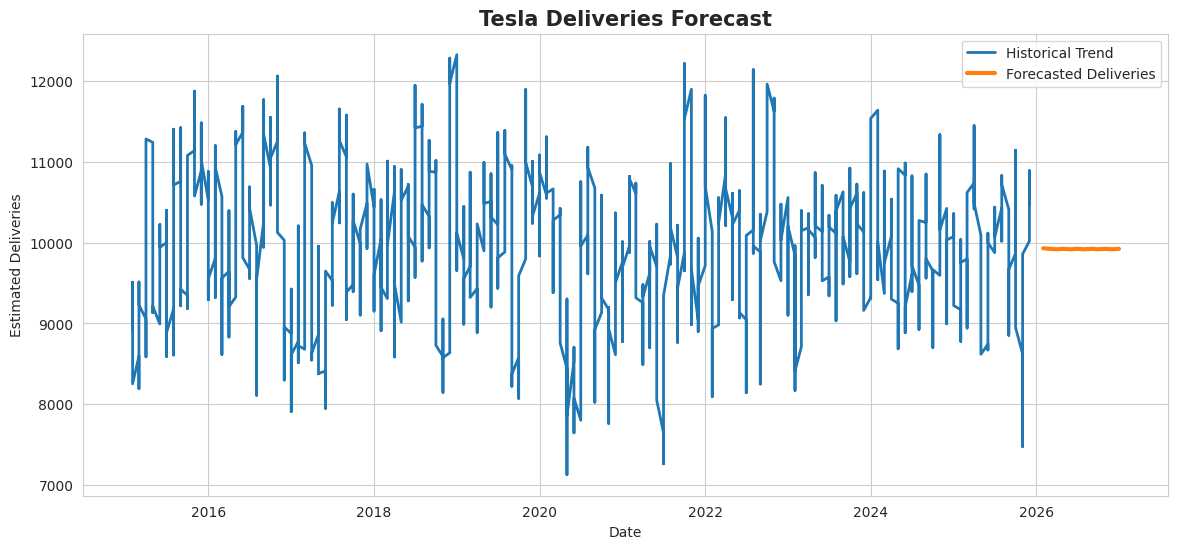

In [128]:
# Forecast Visualization

plt.figure(figsize=(14,6))

# Smoothed Historical Trend
historical_trend = (
    df['Estimated_Deliveries']
    .rolling(window=20)
    .mean()
)

plt.plot(
    df['Date'],
    historical_trend,
    label='Historical Trend',
    linewidth=2
)

# Future Dates
future_dates = pd.date_range(
    start=df['Date'].iloc[-1],
    periods=forecast_steps + 1,
    freq='M'
)[1:]

# Forecast Plot
plt.plot(
    future_dates,
    forecast,
    label='Forecasted Deliveries',
    linewidth=3
)

# Title
plt.title(
    "Tesla Deliveries Forecast",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()
plt.grid(True)

plt.show()

In [129]:
forecast_df = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": final_predictions[:20]
})

forecast_df

,Actual,Predicted
0,10819,10530.74
1,5341,5488.80
2,8195,8055.19
3,8179,8524.28
4,9742,9872.91
5,12266,11869.93
6,7375,7549.53
7,15680,16270.74
8,11323,11888.01
9,11523,11755.70


# Time Series Forecasting Conclusion

The Time Series Forecasting section was implemented using the ARIMA `(2,1,2)` model on Tesla estimated delivery data.

Before applying forecasting, the Augmented Dickey-Fuller (ADF) test was performed to analyze stationarity in the time series data. Since the dataset contained fluctuations and temporal dependencies, first-order differencing (`d=1`) was applied within the ARIMA configuration to handle non-stationarity.

The forecasting visualization showed that future Tesla deliveries are expected to remain relatively stable with moderate fluctuations around the historical trend. The smoothed historical trend and forecast curve demonstrated continuity between past delivery behavior and future estimated values.

The forecasting results indicate that:
- Historical delivery patterns were successfully captured
- The ARIMA model generated stable future predictions
- Delivery trends do not show extreme seasonal or exponential behavior after differencing

Overall, the Time Series Forecasting analysis successfully demonstrated the application of:
- Stationarity testing
- ARIMA modeling
- Trend forecasting
- Future demand estimation

